In [1]:
## Create a vector of the required packages for this analysis
req_packages <- c("ComplexHeatmap", "cowplot", "ggplot2", "ggpubr", "ggrepel", "gridExtra", "janitor",
                  "multcompView", "RColorBrewer", "RUVSeq", "splines", "tidyverse", "vegan", "viridis")

## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

## Investigate Genetic Similarity Between Populations

### Load data

In [2]:
# ## load in filtered snpeff results
# snps <- read_tsv("../workflow/dna/vcf/results/plink/vg_annotated_pruned.vcf", skip = 55) %>%
#     janitor::clean_names() %>%
#     filter(grepl("Chr_", number_chrom))

# ## separate the results information wider
# snps <- snps %>%
#     pivot_longer(10:ncol(snps), names_to = "strain", values_to = "presence") %>%
#     separate_wider_delim(strain, delim = "_", too_many = "drop", names = c("locality", "female", "number")) %>%
#     mutate(strain = paste(locality, female, number, sep = "_"),
#            strain = toupper(strain)) %>%
#     separate_wider_delim(presence, delim = ":", too_many = "drop", 
#                          names = c("genotype")) %>%
#     select(number_chrom, pos, id, ref, alt, strain, genotype) %>%
#     unique()

# write_tsv(snps, "intermediate/full_snps.tsv")

In [3]:
## load in fusion data
snps <- read_tsv("intermediate/full_snps.tsv")
head(snps)

## load in metadata
metadata <- read_csv("input/YABLab_Drosophila_stocks.csv") %>%
    janitor::clean_names() %>%
    filter(!is.na(latitude)) %>%
    mutate(strain_id = str_replace_all(strain_id, "\\.", "_")) %>%
    separate_wider_delim(strain_id, delim = "_", names = c("location", "female", "number"), too_few = "align_start", too_many = "drop", cols_remove = FALSE) %>%
    rename(strain = strain_id) %>%
    filter(!is.na(latitude))
head(metadata)

Rows: 21156135 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): number_chrom, id, ref, alt, strain, genotype
dbl (1): pos

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


number_chrom,pos,id,ref,alt,strain,genotype
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,167416,>5552>5557,GA,TG,BB_05_18,1/1
Chr_2,167416,>5552>5557,GA,TG,BB_05_18,0/0
Chr_2,167416,>5552>5557,GA,TG,BU_06_06,1/1
Chr_2,167416,>5552>5557,GA,TG,BU_06_06,0/0
Chr_2,167416,>5552>5557,GA,TG,BU_06_10,0/0
Chr_2,167416,>5552>5557,GA,TG,CB_05_22,1/1


Rows: 294 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): species_group, Species, strain_ID, strain_type, Genotype, label, s...
dbl  (5): year, latitude, longitude, water_distance_mi, riparian_year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


species_group,species,location,female,number,strain,strain_type,genotype,label,year,⋯,state,country,latitude,longitude,sequencing,wetland,water_distance_mi,water_source,riparian,riparian_year
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
virilis,D. americana,AA,99,06,AA_99_06,wild-type,wt,NA,1999,⋯,AR,USA,35.28654,-91.38307,nextera_2020,No,0.08,Riverine,NA,1980
virilis,D. americana,BB,05,10,BB_05_10,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,18,BB_05_18,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,36,BB_05_36,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,Red,BB_05_Red,mutant,red,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,BB,05,44,BB_05_44,wild-type,wt,NA,2005,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980


### Calculate variation between samples

In [4]:
# # ## create a data frame with the SNP information for each strain
# snps_wide <- snps %>%
#     filter(strain %in% metadata$strain) %>%
#     mutate(allele = case_when(genotype == "1/1" ~ 2,
#                               genotype == "0/1" | genotype == "1/0" ~ 1,
#                               TRUE ~ 0)) %>%
#     group_by(strain, id) %>%
#     reframe(allele = sum(allele)) %>%
#     pivot_wider(names_from = id, values_from = allele) %>%
#     column_to_rownames("strain") %>%
#     mutate_all(~replace_na(., 0))

# # ## calculate principal components
# # snps_pca <- prcomp(snps_wide, retx = TRUE)
# # saveRDS(snps_pca, file = "intermediate/pca.rds")



# ## get the number of chromosomes
# chromosomes <- unique(snps$number_chrom)

# ## calculate principal components for each chromosome and save results as RDS
# for (i in chromosomes) {

#     ## create object name to save
#     snps_pca_name <- paste("intermediate/", i, "_pca.rds")

#     ## get list of SNPs on each chromosome
#     snps_chr <- snps %>%
#         select(number_chrom, id) %>%
#         unique() %>%
#         filter(number_chrom == i)
    
#     ## filter for the SNPs on the select chromosome
#     snps_wide_chr <- snps_wide %>%
#         select(any_of(snps_chr))
    
#     ## calculate prinicipal components
#     snps_pca_chr <- prcomp(snps_wide_chr, retx = TRUE)

#     ## save PC results as an RDS
#     saveRDS(snps_pca_chr, file = snps_pca_name)

# }

In [8]:
## load in total PCA results
snps_pca <- readRDS("intermediate/pca.rds")

In [11]:
## calculate the variance explained by each PC
pca_var <- (snps_pca$sdev)^2

## calculate the proportion of the variance explained by each PC
pca_var_proportion <- pca_var / sum(pca_var)

## count how many principal components are needed to explain at least 90% of the variance
pca_var_count <- which(cumsum(pca_var_proportion) >= 0.9)[1]
pca_var_count

[1] 25

In [80]:
## calculate the percent of total variance that each SNP contributes to explaining the overall genetic diversity
snps_proportion <- snps_pca$rotation*pca_var_proportion

## add the snp information to the total variance explained
snps_chr_proportion <- rowSums(abs(snps_proportion)) %>%
    as.data.frame() %>%
    rename(variance_explained = 1) %>%
    rownames_to_column("id") %>%
    inner_join(snps, by = "id") %>%
    select(id, variance_explained, number_chrom) %>%
    unique()

head(snps_chr_proportion)

,id,variance_explained,number_chrom
,<chr>,<dbl>,<chr>
1,>10000105>10000114,0.005043905,Chr_4
44,>10000152>10000162,0.002644704,Chr_4
93,>10000176>10000228,0.023621454,Chr_4
152,>100001>100003,0.014245194,Chr_2
191,>10000279>10000282,0.002798722,Chr_4
239,>10000304>10000307,0.003195463,Chr_4


In [81]:
## determine if there's a difference in the percent variance explained by each SNP according to chromosome
kruskal.test(variance_explained ~ number_chrom, data = snps_chr_proportion)


	Kruskal-Wallis rank sum test

data:  variance_explained by number_chrom
Kruskal-Wallis chi-squared = 81.064, df = 5, p-value = 5.025e-16


In [85]:
## perform a post hoc test on the chromosome analysis
pairwise.wilcox.test(snps_chr_proportion$variance_explained, snps_chr_proportion$number_chrom, p.adjust.method = "BH")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  snps_chr_proportion$variance_explained and snps_chr_proportion$number_chrom 

      Chr_2   Chr_3   Chr_4   Chr_5  Chr_6 
Chr_3 0.0171  -       -       -      -     
Chr_4 9.2e-06 1.9e-11 -       -      -     
Chr_5 0.0070  0.7236  8.0e-13 -      -     
Chr_6 0.0080  0.0022  0.0636  0.0020 -     
Chr_X 0.7236  0.0361  1.5e-06 0.0127 0.0074

P value adjustment method: BH 

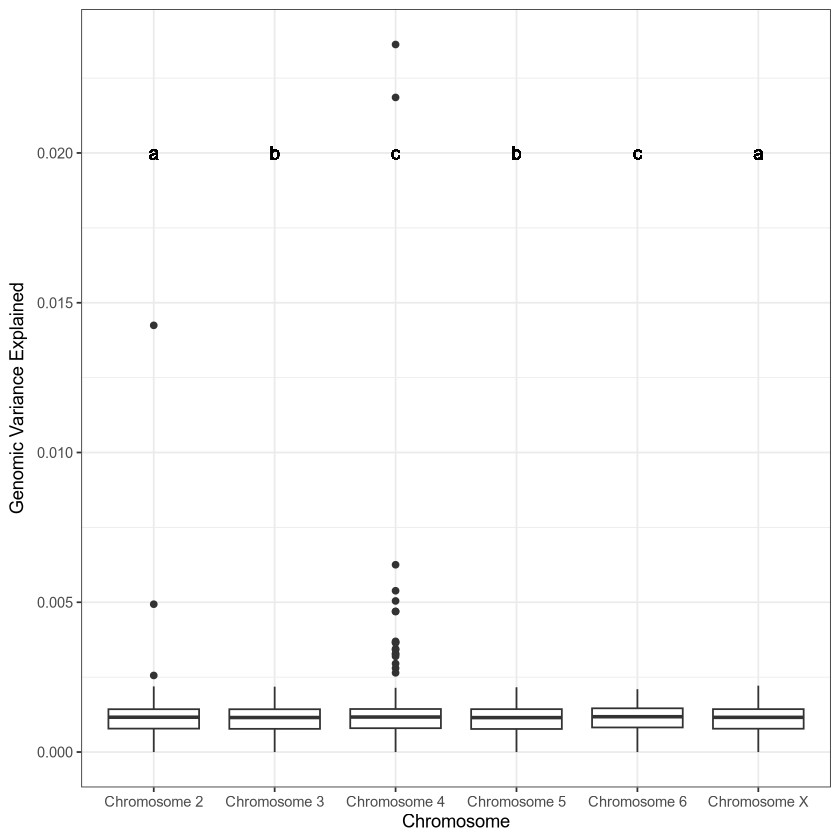

In [88]:
## plot the distribution of total variance explained for SNPs on each chromosome
snps_chr_graph <- snps_chr_proportion %>%
    mutate(group = case_when(number_chrom == "Chr_2" ~ "a",
                             number_chrom == "Chr_3" ~ "b",
                             number_chrom == "Chr_4" ~ "c",
                             number_chrom == "Chr_5" ~ "b",
                             number_chrom == "Chr_6" ~ "c",
                             number_chrom == "Chr_X" ~ "a"),
           number_chrom = str_replace_all(number_chrom, "Chr_", "Chromosome ")) %>%
    ggplot(aes(x = number_chrom, y = variance_explained)) +
        geom_boxplot(aes(y = variance_explained)) +
        geom_text(aes(label = group, y = 0.02)) +
        labs(x = "Chromosome", y = "Genomic Variance Explained") +
        theme_bw()
snps_chr_graph

In [89]:
ggsave("figures/population/pca_explained.png", snps_chr_graph, height = 6, width = 8)

In [133]:
snps_chr_proportion %>%
    arrange(desc(variance_explained)) %>%
    slice(1:20)

id,variance_explained,number_chrom
<chr>,<dbl>,<chr>
>10000176>10000228,0.023621454,Chr_4
>10001131>10001134,0.021854678,Chr_4
>100001>100003,0.014245194,Chr_2
>10000770>10000773,0.006252611,Chr_4
>10000852>10000855,0.005384568,Chr_4
>10000105>10000114,0.005043905,Chr_4
>1000037>1000039,0.004935239,Chr_2
>10001033>10001036,0.004694008,Chr_4
>10000355>10000358,0.004691269,Chr_4


In [111]:
## count the number of SNPs per chromosome
chr_snp_count <- snps %>%
    select(number_chrom, id) %>%
    unique() %>%
    group_by(number_chrom) %>%
    count() %>%
    rename(total = n)

## find the SNPs that explain the highest proportion of variance
top_25_variants <- snps_chr_proportion %>%
    arrange(desc(variance_explained)) %>% 
    slice(1:(nrow(snps_chr_proportion)/4)) %>%
    group_by(number_chrom) %>%
    count() %>%
    full_join(chr_snp_count, by = "number_chrom") %>%
    mutate(percent = n/total)
top_25_variants

number_chrom,n,total,percent
<chr>,<int>,<int>,<dbl>
Chr_2,22145,89384,0.2477513
Chr_3,18176,73705,0.2466047
Chr_4,23379,91805,0.2546593
Chr_5,19965,79973,0.2496468
Chr_6,488,1750,0.2788571
Chr_X,23543,94170,0.2500053


In [131]:
## determine if there is an enrichment of SNPs on the fourth chromosome in the top 25% of variants
snps_chr_fourth <- snps_chr_proportion %>%
    arrange(desc(variance_explained)) %>% 
    slice(1:(nrow(snps_chr_proportion)/4)) %>%
    group_by(number_chrom) %>%
    count() %>%
    full_join(chr_snp_count, by = "number_chrom") %>%
    mutate(chromosome = case_when(number_chrom == "Chr_4" ~ "fourth",
                                  TRUE ~ "other")) %>%
    group_by(chromosome) %>%
    reframe(top_25 = sum(n), total = sum(total)) %>%
    column_to_rownames("chromosome") %>%
    t()
snps_chr_fourth
snps_chr_fourth %>%
    chisq.test

,fourth,other
top_25,23379,84317
total,91805,338982



	Pearson's Chi-squared test with Yates' continuity correction

data:  .
X-squared = 8.0655, df = 1, p-value = 0.004512


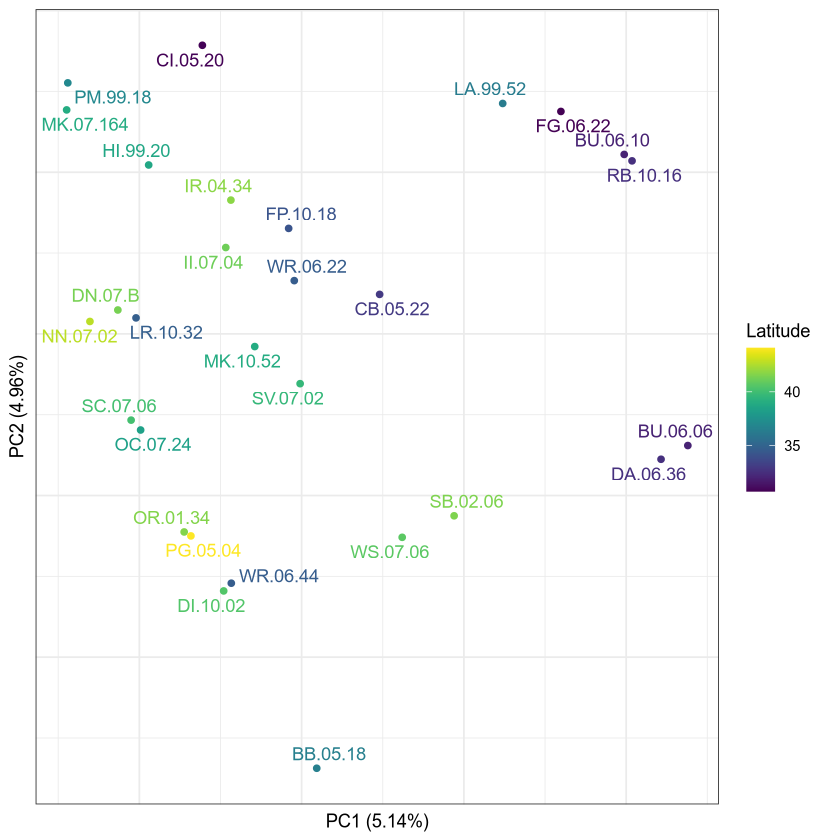

In [46]:
## plot the proportion of variance explained by each PC
pca_var_proportion_graph <- snps_pca$x %>%
    as.data.frame() %>%
    select(PC1, PC2) %>%
    rownames_to_column("strain") %>%
    inner_join(metadata, by = "strain") %>%
    mutate(strain = str_replace_all(strain, "_", ".")) %>%
    ggplot(aes(x = PC1, y = PC2, color = latitude)) +
        geom_point() +
        geom_text_repel(aes(label = strain)) +
        labs(x = paste0("PC1 (", round(pca_var_proportion[1]*100, 2), "%)"), 
             y = paste0("PC2 (", round(pca_var_proportion[2]*100, 2), "%)"),
             color = "Latitude") +
        scale_color_viridis() +
        theme_bw() +
        theme(axis.ticks = element_blank(),
              axis.text = element_blank())
pca_var_proportion_graph

In [47]:
ggsave("figures/population/whole_pca.png", pca_var_proportion_graph, height = 6, width = 8)

In [ ]:
## determine if any specific chromosome explains a higher amount of the variation
### multiple the percent explained by each loading by the percent explained by the relevant principal component
### add the percent explained for each chromosome for each loading and then perform a Kruskal-Wallis test between chromosomes

### Calculate variation between samples, per chromosome

In [ ]:
# ## load PCA results for each chromosome
# snps_pca2 <- readRDS("intermediate/Chr_2_pca.rds")
# snps_pca3 <- readRDS("intermediate/Chr_3_pca.rds")
# snps_pca4 <- readRDS("intermediate/Chr_4_pca.rds")
# snps_pca5 <- readRDS("intermediate/Chr_5_pca.rds")
# snps_pca6 <- readRDS("intermediate/Chr_6_pca.rds")
# snps_pcax <- readRDS("intermediate/Chr_X_pca.rds")

## Investigate Sequence Diversity Across Species

### Calculate nucleotide diversity

### Calculate nucleotide diversity relative to distance to the centromere

## Investigate Sequence Diversity Across Populations

### Load data

### Calculate nucleotide diversity for each population

### Calculate nucleotide diversity for each chromosome per population

### Calculate correlation between nucleotide diversity and latitude

### Calculate correlation between nucleotide diversity and longitude

### Calculate nucleotide diversity relative to distance to the centromere for each population

## Investigate Heterozygosity Across Populations

### Calculate heterozygosity across the whole species

In [137]:
## count the number of strains per population
strain_pop <- snps %>%
    select(number_chrom, pos, alt, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location) %>%
    count() %>%
    rename(total = n)

## count the number of heterozygotes
het_pop <- snps %>%
    filter((genotype == "1/0" | genotype == "0/1")) %>%
    select(number_chrom, pos, alt, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location, genotype) %>%
    count() %>%
    mutate_all(n = replace_na(n, 0)) %>%
    left_join(strain_pop, by = c("number_chrom", "pos", "alt", "location")) %>%
    mutate(het_freq = n/total)
head(het_pop)

`mutate_all()` ignored the following grouping variables:
• Columns `number_chrom`, `pos`, `alt`, `location`, `genotype`
ℹ Use `mutate_at(df, vars(-group_cols()), myoperation)` to silence the message.


number_chrom,pos,alt,location,genotype,n,total,het_freq
<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
Chr_2,171478,CT,BB,0/1,1,1,1
Chr_2,171478,CT,CB,0/1,1,1,1
Chr_2,171478,CT,DA,0/1,1,1,1
Chr_2,171478,CT,FG,0/1,1,1,1
Chr_2,171478,CT,HI,0/1,1,1,1
Chr_2,195481,C,DI,0/1,1,1,1


In [138]:
## create empty data frame to populate
number_chrom <- unique(het_pop$number_chrom)

het_pop_ttest <- matrix(data = NA, nrow = 1, ncol = 3,
                        dimnames = list(c("remove"),
                                        c("number_chrom", "location", "p_value"))) %>%
                as.data.frame()

## calculate how much the heterozygosity frequency deviates from expected for each location per chromosome
for (i in number_chrom) {
    
    ## pull the list of heterozygosity frequencies for the entire chromosome, across populations
    y <-  het_pop %>%
        filter(number_chrom == i) %>%
        pull("het_freq")

    for (j in unique(het_pop$location)) {    
        
        ## pull the heterozygosity frequencies for the location on chromosome
        x <- het_pop %>%
            filter(number_chrom == i & location == j) %>%
            pull("het_freq")
            
        if (length(x) > 2) {        
            ## run the t-test
            test <- t.test(x = x, y = y, alternative = "greater", var.equal = FALSE)

            ## populate the data frame
            het_pop_ttest <- het_pop_ttest %>%
                add_row(number_chrom = i, location = j, p_value = test$p.value)

        }
    }
}

## filter out the removed row
het_pop_ttest <- het_pop_ttest %>%
    na.omit()
head(het_pop_ttest)

,number_chrom,location,p_value
,<chr>,<chr>,<dbl>
...2,Chr_2,BB,0
...3,Chr_2,CB,0
...4,Chr_2,DA,0
...5,Chr_2,FG,0
...6,Chr_2,HI,0
...7,Chr_2,DI,0


In [139]:
## calculate the average heterozygosity per chromosome
chrom_het_avg <- het_pop %>%
    group_by(number_chrom) %>%
    summarize(probability = mean(het_freq))

## plot the number of populations that deviate from the chromosomal mean
het_graph_deviate <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location", relationship = "many-to-many") %>%
    filter(total > 2) %>%
    na.omit() %>%
    left_join(het_pop_ttest, by = c("number_chrom", "location"), relationship = "many-to-many") %>%
    left_join(chrom_het_avg, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(deviate = case_when(p_value < 0.05 ~ 1.25,
                               TRUE ~ NA)) %>%
    ggplot() +
        geom_boxplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude), outlier.shape = NA) +
        geom_hline(aes(yintercept = probability), linetype = "dashed") +
        geom_point(aes(x = fct_reorder(location, latitude), y = deviate)) +
        labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
        scale_fill_viridis() +
        theme_bw() +
        theme(panel.grid = element_blank(),
            legend.position = "bottom") +
        facet_wrap(~number_chrom)
het_graph_deviate

ERROR while rich displaying an object: Error in `combine_vars()`:
! Faceting variables must have at least one value.

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 .

In [140]:
ggsave("figures/population/heterozygosity_pop.png", het_graph_deviate, height = 6, width = 12)

ERROR: [1m[33mError[39m in `combine_vars()`:[22m
[1m[22m[33m![39m Faceting variables must have at least one value.


### Calculate heterozygosity for each population

### Calculate correlation between latitude and heterozygosity

### Calculate correlation between longitude and heterozygosity

## Investigate Fixation and Isolation by Distance

### Load data

### Calculate Fst across all populations, relative to distance

### Determine if there are specific sites/windows where Fst does correlate to distance

## Investigate Transposable Element Frequency Across Populations

### Load data

### Determine average coverage across whole species

### Determine coverage for each population